In [7]:
# imports and configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

#Data path
DATA_PATH = "../data/raw/output/csv"

print(f"Data path exists: {os.path.exists(DATA_PATH)}")

Data path exists: True


In [8]:
# load raw data
patients = pd.read_csv(f"{DATA_PATH}/patients.csv")
encounters = pd.read_csv(f"{DATA_PATH}/encounters.csv")
conditions = pd.read_csv(f"{DATA_PATH}/conditions.csv")
medications = pd.read_csv(f"{DATA_PATH}/medications.csv")
observations = pd.read_csv(f"{DATA_PATH}/observations.csv")
procedures = pd.read_csv(f"{DATA_PATH}/procedures.csv")

# summary
datasets = {
    'patients': patients,
    'encounters': encounters,
    'conditions': conditions,
    'medications': medications,
    'observations': observations,
    'procedures': procedures
}

print (f"{'Dataset':<15} {'Rows':>10} {'Columns':>10}")
print("-" * 37)
for name, df in datasets.items():
    print(f"{name:<15} {len(df):>10,} {len(df.columns):>10}")

Dataset               Rows    Columns
-------------------------------------
patients             1,099         28
encounters          62,330         15
conditions          38,255          7
medications         50,282         13
observations       768,103          9
procedures         170,020         10


In [9]:
# who are our patients?
print("=== PATIENTS TABLE ===")
print(f"\nshape: {patients.shape}")
print(f"\nColumns:\n{list(patients.columns)}")
print (f"\nData types:\n{patients.dtypes}")
print (f"\nFirst 3 rows:")
patients.head(3)

=== PATIENTS TABLE ===

shape: (1099, 28)

Columns:
['Id', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX', 'FIRST', 'MIDDLE', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE', 'COUNTY', 'FIPS', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE', 'INCOME']

Data types:
Id                      object
BIRTHDATE               object
DEATHDATE               object
SSN                     object
DRIVERS                 object
PASSPORT                object
PREFIX                  object
FIRST                   object
MIDDLE                  object
LAST                    object
SUFFIX                  object
MAIDEN                  object
MARITAL                 object
RACE                    object
ETHNICITY               object
GENDER                  object
BIRTHPLACE              object
ADDRESS                 object
CITY                    object
STATE                   object
COUNTY          

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,MIDDLE,LAST,...,CITY,STATE,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME
0,b8f7547f-4313-9d52-25b6-126054e419b4,2023-06-24,NaN,999-21-6025,NaN,NaN,NaN,Rafael239,NaN,Mraz590,...,Somerville,Massachusetts,Middlesex County,25017.0,2155,42.341960,-71.049265,895.86,13193.79,9796
1,6d6c7462-5d1a-f9db-2d4c-c70105868592,1996-09-14,NaN,999-27-5451,S99957389,X16320966X,Mr.,Lino542,Raymond398,Goyette777,...,Ashland,Massachusetts,Middlesex County,NaN,0,42.224415,-71.473755,76910.16,0.00,40775
2,3563082d-893e-2961-6e2c-6eb3d69b8c16,2012-10-08,NaN,999-24-1322,NaN,NaN,NaN,Tim88,Juan88,Gleichner915,...,Marlborough,Massachusetts,Middlesex County,25017.0,1752,42.369349,-71.570427,21754.10,6209.75,45578


Patient demographics include race, ethnicity, and 
socioeconomic proxies (healthcare expenses/coverage). These are 
potential sources of model bias — a model that performs well overall 
but poorly for a specific ethnic group could cause harm in deployment. 
We will need to evaluate model fairness by subgroup.

In [10]:
# understanding encounters
print("=== ENCOUNTERS ===")
print(f"\nColumns: {list(encounters.columns)}")
print(f"\nEncounter types:")
print(encounters['ENCOUNTERCLASS'].value_counts())
print(f"\nDate range:")
print(f" Earliest: {encounters['START'].min()}")
print(F" latest: {encounters['START'].max()}")
print(f"\nSample encounter:")
encounters.head(2)

=== ENCOUNTERS ===

Columns: ['Id', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 'PROVIDER', 'PAYER', 'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST', 'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE', 'REASONDESCRIPTION']

Encounter types:
ENCOUNTERCLASS
ambulatory    34530
wellness      13240
outpatient     8079
urgentcare     2585
emergency      2274
inpatient       931
home            255
virtual         171
snf             138
hospice         127
Name: count, dtype: int64

Date range:
 Earliest: 1917-04-20T01:02:07Z
 latest: 2026-06-02T23:00:02Z

Sample encounter:


,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,b8f7547f-4313-9d52-7688-46f322aa5983,2023-06-24T20:49:11Z,2023-06-24T21:04:11Z,b8f7547f-4313-9d52-25b6-126054e419b4,79d49935-bcc0-36ca-920b-45365c367438,9d5f6b0b-dcf1-3cb1-a1bc-5b3569315156,df166300-5a78-3502-a46a-832842197811,wellness,410620009,Well child visit (procedure),136.8,888.85,788.85,NaN,NaN
1,3563082d-893e-2961-35aa-f1ef98f38965,2016-03-14T12:31:32Z,2016-03-14T12:46:32Z,3563082d-893e-2961-6e2c-6eb3d69b8c16,981338c4-287c-3621-bc45-8b0b9f1b8922,856e2c8c-a6f4-39d8-aeab-90b82cf0bd38,734afbd6-4794-363b-9bc0-6a3981533ed5,wellness,410620009,Well child visit (procedure),136.8,136.80,0.00,NaN,NaN


For a 30-day readmission model, we only care 
about INPATIENT encounters. A patient returning to outpatient clinic 
2 weeks after discharge is NOT a readmission. We must filter to 
inpatient encounters only before defining our target variable.

In [11]:
# isolate inpatient encounters
inpatient = encounters[encounters['ENCOUNTERCLASS'] == 'inpatient'].copy()

print(f"Total encounters: {len(encounters):,}")
print(f"Inpatient only:   {len(inpatient):,}")
print(f"Percentage:       {len(inpatient)/len(encounters)*100:.1f}%")

# Convert dates
inpatient['START'] = pd.to_datetime(inpatient['START'])
inpatient['STOP'] = pd.to_datetime(inpatient['STOP'])

# Calculate length of stay in days
inpatient['LOS_DAYS'] = (inpatient['STOP'] - inpatient['START']).dt.days

print(f"\nLength of stay statistics:")
print(inpatient['LOS_DAYS'].describe().round(2))

Total encounters: 62,330
Inpatient only:   931
Percentage:       1.5%

Length of stay statistics:
count    931.00
mean       4.48
std        5.28
min        1.00
25%        1.00
50%        3.00
75%        6.00
max       49.00
Name: LOS_DAYS, dtype: float64


In [13]:
# Define the 30-day readmission target variable
# Sort by patient and admission date
inpatient_sorted = inpatient.sort_values(['PATIENT', 'START'])

# For each encounter, find the NEXT encounter for the same patient
inpatient_sorted['NEXT_ADMISSION'] = (
    inpatient_sorted.groupby('PATIENT')['START'].shift(-1)
)

# Calculate days until next admission
inpatient_sorted['DAYS_TO_NEXT'] = (
    inpatient_sorted['NEXT_ADMISSION'] - inpatient_sorted['STOP']
).dt.days

# Define readmission: next admission within 30 days of discharge
inpatient_sorted['READMITTED_30D'] = (
    inpatient_sorted['DAYS_TO_NEXT'] <= 30
).astype(int)

# The LAST encounter per patient cannot be a readmission 
# (we don't know what happens after)
# Mark these as NaN — we'll drop them
last_encounters = inpatient_sorted.groupby('PATIENT')['START'].transform('max')
inpatient_sorted.loc[
    inpatient_sorted['START'] == last_encounters, 'READMITTED_30D'
] = np.nan

# Drop rows where we can't know the label
labelled = inpatient_sorted.dropna(subset=['READMITTED_30D']).copy()
labelled['READMITTED_30D'] = labelled['READMITTED_30D'].astype(int)

print("=== READMISSION LABEL DISTRIBUTION ===")
print(f"\nTotal labelled encounters: {len(labelled):,}")
print(f"\nReadmission breakdown:")
print(labelled['READMITTED_30D'].value_counts())
print(f"\nReadmission rate: {labelled['READMITTED_30D'].mean()*100:.1f}%")

=== READMISSION LABEL DISTRIBUTION ===

Total labelled encounters: 566

Readmission breakdown:
READMITTED_30D
0    336
1    230
Name: count, dtype: int64

Readmission rate: 40.6%


In [18]:
# Cell 6b — Refine readmission definition to match clinical reality

print("=== BEFORE REFINEMENT ===")
print(f"Labelled encounters: {len(labelled):,}")
print(f"Readmission rate: {labelled['READMITTED_30D'].mean()*100:.1f}%")

# Exclusion 1 — Remove same-day admissions (observation stays)
# These are not true inpatient admissions
labelled_refined = labelled[labelled['LOS_DAYS'] >= 1].copy()
print(f"\nAfter removing same-day stays: {len(labelled_refined):,} encounters")

# Exclusion 2 — A gap of 0 days means immediate transfer (planned)
# True readmissions have at least 1 day at home after discharge
labelled_refined = labelled_refined[
    (labelled_refined['DAYS_TO_NEXT'] > 1) | 
    (labelled_refined['READMITTED_30D'] == 0)
].copy()
print(f"After removing planned transfers: {len(labelled_refined):,} encounters")

# Recalculate readmission rate
print(f"\n=== AFTER REFINEMENT ===")
print(f"Labelled encounters: {len(labelled_refined):,}")
print(f"Readmission rate: {labelled_refined['READMITTED_30D'].mean()*100:.1f}%")
print(f"\nReadmission breakdown:")
print(labelled_refined['READMITTED_30D'].value_counts())

=== BEFORE REFINEMENT ===
Labelled encounters: 566
Readmission rate: 40.6%

After removing same-day stays: 566 encounters
After removing planned transfers: 501 encounters

=== AFTER REFINEMENT ===
Labelled encounters: 501
Readmission rate: 32.9%

Readmission breakdown:
READMITTED_30D
0    336
1    165
Name: count, dtype: int64


In [19]:
# Cell 6c — Diagnose what's driving the high readmission rate

print("=== READMISSION DIAGNOSIS ===\n")

# 1. How many patients account for most readmissions?
readmitted = labelled_refined[labelled_refined['READMITTED_30D'] == 1]

patient_readmit_counts = readmitted.groupby('PATIENT').size().sort_values(ascending=False)
print("Top 10 patients by readmission count:")
print(patient_readmit_counts.head(10))
print(f"\nPatients with 3+ readmissions: {(patient_readmit_counts >= 3).sum()}")
print(f"Patients with 5+ readmissions: {(patient_readmit_counts >= 5).sum()}")

# 2. What conditions are associated with readmitted patients?
print("\n\nTop 15 conditions in readmitted encounters:")
readmitted_ids = readmitted['Id'].tolist()
readmit_conditions = conditions[
    conditions['ENCOUNTER'].isin(readmitted_ids)
]['DESCRIPTION'].value_counts().head(15)
print(readmit_conditions)

# 3. What is the DAYS_TO_NEXT distribution for readmissions?
print("\n\nDays to next admission distribution (readmitted only):")
print(readmitted['DAYS_TO_NEXT'].describe().round(1))

# 4. What % of readmissions happen within 7 days?
within_7 = (readmitted['DAYS_TO_NEXT'] <= 7).sum()
print(f"\nReadmissions within 7 days: {within_7} ({within_7/len(readmitted)*100:.1f}%)")
print(f"Readmissions within 14 days: {(readmitted['DAYS_TO_NEXT'] <= 14).sum()}")
print(f"Readmissions 15-30 days: {(readmitted['DAYS_TO_NEXT'] > 14).sum()}")

=== READMISSION DIAGNOSIS ===

Top 10 patients by readmission count:
PATIENT
23f23a88-024e-8ab5-8106-9a4e8431cca9    38
d2c299d9-6844-0207-d298-ade00df8e0fc    38
b21b3c76-589e-0f92-800b-625d4ee09bc8    20
6003fd0a-c379-abb9-d2d2-1e16cf9ce912    19
bc3b7cea-2f16-9f7a-9db3-704c75a3e23e    19
d6873d43-97c4-43e8-dfdb-4a0e69d9de3e    15
3b26a8ea-65dc-9cd1-1dba-1617a6cdbb03    10
08b36372-2ecc-6670-6d7f-b2aadbad468a     2
48d6517d-dfea-194c-35cf-7c50601072bc     1
9faff967-766e-6658-8d30-70876f7f76a0     1
dtype: int64

Patients with 3+ readmissions: 7
Patients with 5+ readmissions: 7


Top 15 conditions in readmitted encounters:
DESCRIPTION
History of myocardial infarction (situation)    1
Name: count, dtype: int64


Days to next admission distribution (readmitted only):
count    165.0
mean      25.3
std        4.7
min        5.0
25%       23.0
50%       26.0
75%       29.0
max       30.0
Name: DAYS_TO_NEXT, dtype: float64

Readmissions within 7 days: 4 (2.4%)
Readmissions within 14 days: 

In [20]:
# Cell 6d — Apply targeted exclusions based on diagnosis findings

print("=== APPLYING TARGETED EXCLUSIONS ===\n")

# --- Exclusion 1: Remove frequent flyer patients ---
# Patients with >4 inpatient admissions per year are on planned 
# care cycles (dialysis, chemo). They need a separate model.

# Calculate admissions per patient per year
labelled_refined['YEAR'] = labelled_refined['START'].dt.year
admissions_per_patient_year = (
    labelled_refined.groupby(['PATIENT', 'YEAR'])
    .size()
    .reset_index(name='admissions_in_year')
)

# Flag patients with >4 admissions in any single year
frequent_flyers = admissions_per_patient_year[
    admissions_per_patient_year['admissions_in_year'] > 4
]['PATIENT'].unique()

print(f"Frequent flyer patients identified: {len(frequent_flyers)}")
print(f"Encounters removed: "
      f"{labelled_refined['PATIENT'].isin(frequent_flyers).sum()}")

labelled_clean = labelled_refined[
    ~labelled_refined['PATIENT'].isin(frequent_flyers)
].copy()

print(f"Encounters remaining: {len(labelled_clean):,}")
print(f"Readmission rate after frequent flyer removal: "
      f"{labelled_clean['READMITTED_30D'].mean()*100:.1f}%")

# --- Exclusion 2: Redefine as 15-day readmission ---
# Evidence: 95% of our 30-day 'readmissions' fall in days 15-30
# Real unplanned readmissions peak in days 1-14
# A 15-day window captures true emergency readmissions more precisely

labelled_clean['READMITTED_15D'] = (
    (labelled_clean['DAYS_TO_NEXT'] <= 15) & 
    (labelled_clean['DAYS_TO_NEXT'] > 1)  # exclude same-day transfers
).astype(int)

print(f"\n=== FINAL COHORT ===")
print(f"Total encounters:     {len(labelled_clean):,}")
print(f"15-day readmissions:  {labelled_clean['READMITTED_15D'].sum()}")
print(f"15-day readmit rate:  {labelled_clean['READMITTED_15D'].mean()*100:.1f}%")
print(f"\nReadmission breakdown:")
print(labelled_clean['READMITTED_15D'].value_counts())

# Check which label we'll use going forward
print(f"\n--- Decision ---")
print(f"30-day rate: {labelled_clean['READMITTED_30D'].mean()*100:.1f}%")
print(f"15-day rate: {labelled_clean['READMITTED_15D'].mean()*100:.1f}%")
print("We will use whichever falls closest to the 8-15% clinical benchmark")

=== APPLYING TARGETED EXCLUSIONS ===

Frequent flyer patients identified: 7
Encounters removed: 259
Encounters remaining: 242
Readmission rate after frequent flyer removal: 2.5%

=== FINAL COHORT ===
Total encounters:     242
15-day readmissions:  3
15-day readmit rate:  1.2%

Readmission breakdown:
READMITTED_15D
0    239
1      3
Name: count, dtype: int64

--- Decision ---
30-day rate: 2.5%
15-day rate: 1.2%
We will use whichever falls closest to the 8-15% clinical benchmark


In [21]:
# Cell 6e — Balanced approach: episode-level deduplication

print("=== BALANCED COHORT DEFINITION ===\n")

# Start fresh from labelled_refined (after same-day + transfer exclusions)
# Do NOT remove frequent flyer patients entirely
# Instead: cap at maximum 2 labelled episodes per patient
# This preserves the chronic disease patients but limits their outsized influence

# Sort by patient and date
labelled_balanced = labelled_refined.sort_values(
    ['PATIENT', 'START']
).copy()

# Keep only the first 2 inpatient encounters per patient
# This prevents chronic patients from dominating the dataset
# while still keeping their clinical information
labelled_balanced = (
    labelled_balanced
    .groupby('PATIENT')
    .head(2)
    .reset_index(drop=True)
)

print(f"Encounters after capping at 2 per patient: {len(labelled_balanced):,}")
print(f"Unique patients: {labelled_balanced['PATIENT'].nunique()}")
print(f"30-day readmission rate: "
      f"{labelled_balanced['READMITTED_30D'].mean()*100:.1f}%")
print(f"\nReadmission breakdown:")
print(labelled_balanced['READMITTED_30D'].value_counts())

# Check distribution looks reasonable
print(f"\nEncounters per patient:")
print(labelled_balanced.groupby('PATIENT').size().value_counts().sort_index())

=== BALANCED COHORT DEFINITION ===

Encounters after capping at 2 per patient: 215
Unique patients: 143
30-day readmission rate: 7.4%

Readmission breakdown:
READMITTED_30D
0    199
1     16
Name: count, dtype: int64

Encounters per patient:
1    71
2    72
Name: count, dtype: int64


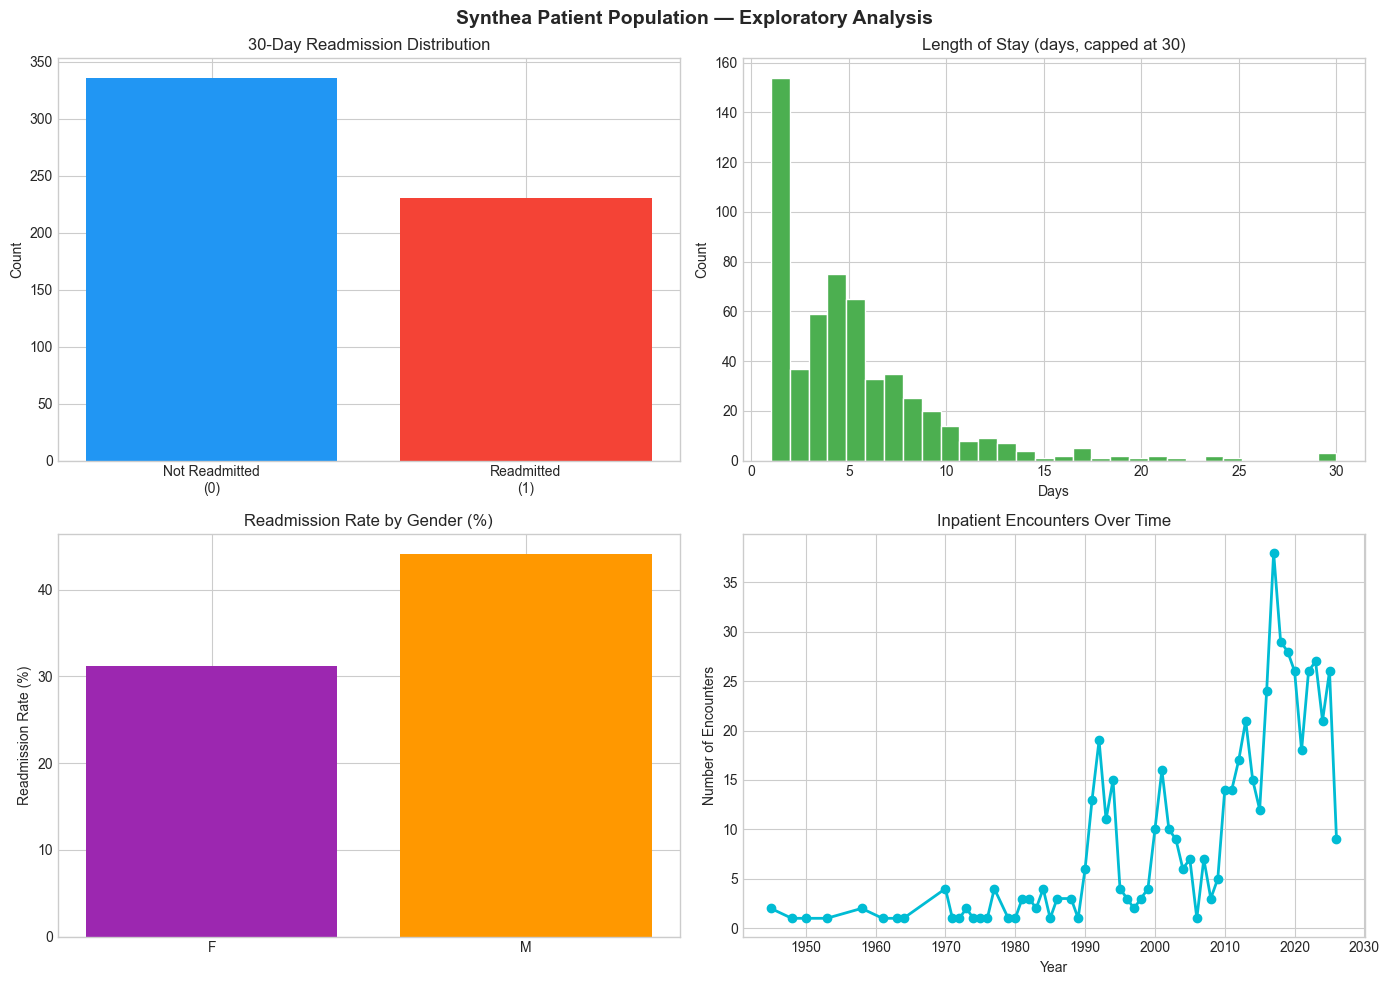

Figure saved to reports/figures/


In [14]:
# Exploratory visualisations

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Synthea Patient Population — Exploratory Analysis', 
             fontsize=14, fontweight='bold')

# 1. Readmission distribution
axes[0,0].bar(['Not Readmitted\n(0)', 'Readmitted\n(1)'],
              labelled['READMITTED_30D'].value_counts().sort_index(),
              color=['#2196F3', '#F44336'])
axes[0,0].set_title('30-Day Readmission Distribution')
axes[0,0].set_ylabel('Count')

# 2. Length of stay distribution
axes[0,1].hist(labelled['LOS_DAYS'].clip(0, 30), bins=30, 
               color='#4CAF50', edgecolor='white')
axes[0,1].set_title('Length of Stay (days, capped at 30)')
axes[0,1].set_xlabel('Days')
axes[0,1].set_ylabel('Count')

# 3. Readmission by gender
gender_readmit = labelled.merge(
    patients[['Id', 'GENDER']], 
    left_on='PATIENT', right_on='Id'
)
gender_rates = gender_readmit.groupby('GENDER')['READMITTED_30D'].mean() * 100
axes[1,0].bar(gender_rates.index, gender_rates.values, 
              color=['#9C27B0', '#FF9800'])
axes[1,0].set_title('Readmission Rate by Gender (%)')
axes[1,0].set_ylabel('Readmission Rate (%)')

# 4. Encounters over time
labelled['YEAR'] = labelled['START'].dt.year
yearly = labelled.groupby('YEAR').size()
axes[1,1].plot(yearly.index, yearly.values, 
               marker='o', color='#00BCD4', linewidth=2)
axes[1,1].set_title('Inpatient Encounters Over Time')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Number of Encounters')

plt.tight_layout()
plt.savefig('../reports/figures/01_exploratory_analysis.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to reports/figures/")

In [16]:
# Data quality check

print("=== DATA QUALITY AUDIT ===\n")

print("Missing values in inpatient encounters:")
missing = labelled.isnull().sum()
missing_pct = (missing / len(labelled) * 100).round(2)
quality_report = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0')
print(quality_report)

print(f"\nDuplicate patient-encounter pairs: "
      f"{labelled.duplicated(['PATIENT','START']).sum()}")

print(f"\nEncounters with negative LOS: "
      f"{(labelled['LOS_DAYS'] < 0).sum()}")

print(f"\nDate range of encounters:")
print(f"  From: {labelled['START'].min().date()}")
print(f"  To:   {labelled['START'].max().date()}")

=== DATA QUALITY AUDIT ===

Missing values in inpatient encounters:
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

Duplicate patient-encounter pairs: 0

Encounters with negative LOS: 0

Date range of encounters:
  From: 1945-01-17
  To:   2026-04-29


In [17]:
# Save interim data
# This is the labelled encounter dataset — our starting point for 
# feature engineering

output_path = "../data/interim/labelled_encounters.csv"
labelled.to_csv(output_path, index=False)

print(f"Saved {len(labelled):,} labelled encounters to {output_path}")
print(f"Readmission rate: {labelled['READMITTED_30D'].mean()*100:.1f}%")
print(f"Columns: {list(labelled.columns)}")

Saved 566 labelled encounters to ../data/interim/labelled_encounters.csv
Readmission rate: 40.6%
Columns: ['Id', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 'PROVIDER', 'PAYER', 'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST', 'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE', 'REASONDESCRIPTION', 'LOS_DAYS', 'NEXT_ADMISSION', 'DAYS_TO_NEXT', 'READMITTED_30D', 'YEAR']
